# notebook74ee1fd78b

This notebook documents an NLP experiment, including dataset handling, model configuration, and iterative testing.

This file keeps the original experimentation style and adds a small structure note for easier navigation.


In [ ]:
!pip install bitsandbytes

In [ ]:
!pip install  transformers==4.53.3

In [ ]:
!pip install flash-attn==2.5.8

In [ ]:


!pip install unsloth==2025.3.14
!pip install unsloth-zoo==2025.3.12

In [1]:
import pandas as pd
import torch
from unsloth import FastLanguageModel

from transformers import AutoTokenizer, AutoModelForCausalLM,BitsAndBytesConfig,HqqConfig
from peft import PeftModel, PeftConfig, LoraConfig, get_peft_model,prepare_model_for_kbit_training,XLoraConfig,IA3Config


import matplotlib.pyplot as plt
from IPython.display import clear_output
import json
import ast
import random
import itertools
from bitsandbytes.optim import AdamW8bit
from accelerate import prepare_pippy
import requests


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-08-04 18:13:09.162919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754331189.188870     430 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754331189.200194     430 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
import random

def recursive_random_drop(data, drop_prob=0.3):
    """
    Recursively drops keys from dictionaries or elements from iterables with a given probability.
    
    Args:
        data: The input data (dict, list, set, tuple, or primitive).
        drop_prob: The probability of dropping a key/item (0.0 to 1.0).
    
    Returns:
        A new data structure with some elements dropped.
    """
    if isinstance(data, dict):
        return {
            k: recursive_random_drop(v, drop_prob)
            for k, v in data.items()
            if random.random() > drop_prob
        }
    elif isinstance(data, list):
        return [
            recursive_random_drop(item, drop_prob)
            for item in data
            if random.random() > drop_prob
        ]
    elif isinstance(data, set):
        return {
            recursive_random_drop(item, drop_prob)
            for item in data
            if random.random() > drop_prob
        }
    elif isinstance(data, tuple):
        return tuple(
            recursive_random_drop(item, drop_prob)
            for item in data
            if random.random() > drop_prob
        )
    else:
        return data

In [ ]:
testset.iloc[0].response

In [ ]:
testset.iloc[20:]
seq_log=testset.dropna()

In [ ]:
seq_log.response[10]

In [ ]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

In [ ]:
quant_config = HqqConfig(
    nbits=4,group_size=64)

In [ ]:


model= AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B", quantization_config=quant_config,device_map="cuda",attn_implementation="flash_attention_2",torch_dtype=torch.bfloat16)
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-0.6B")


In [ ]:
model= AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B",device_map="cuda",attn_implementation="flash_attention_2",torch_dtype=torch.bfloat16)
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-0.6B")


In [ ]:
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-0.6B")

In [ ]:
model=AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",device_map="auto")
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct")

In [ ]:
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct")

In [ ]:
data= pd.read_csv("data/qwen_def_data.csv")
data=data.sample(frac=1).reset_index(drop=True)
train,eval=data[:int(len(data)*0.9)],data[int(len(data)*0.9):]


In [ ]:
data.iloc[100].query

In [ ]:
config_l=LoraConfig(
    r=7,
    lora_alpha=40,
    lora_dropout=0.3,
    bias="none",
    target_modules=["q_proj", "v_proj","o_proj","gate_proj","up_proj","down_proj"],
    
)

In [ ]:
model

In [ ]:
print(model.adapter_summary())

In [ ]:
model

In [ ]:
model.train

In [ ]:
model.train_adapter("qwen_task_reforce")

In [ ]:
#print model datatypes
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.dtype}")

In [ ]:
model.adapter_to("qwen_task1",device="cuda")

In [ ]:
#model=prepare_model_for_kbit_training(model)
peft_config = LoraConfig(
    r=7,
    lora_alpha=40,
    bias="none",
    target_modules=["q_proj", "v_proj","o_proj","gate_proj","up_proj","down_proj"],
    
    
    
)
model = get_peft_model(model, peft_config,adapter_name="qwen_task2")
model.print_trainable_parameters()


In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
model.print_trainable_parameters()

In [ ]:
model

In [ ]:
#set qwen_task1

In [ ]:

model.load_adapter("./qwen_task_1","ad_2")

In [ ]:
model.base_model.set_adapter(["ad_2","qwen_task1"])

In [ ]:
#print trainable parameters
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

In [ ]:
model.print_trainable_parameters()


In [ ]:
model.config.use_cache = False

In [ ]:
model=prepare_model_for_kbit_training(model)
peft_config = xlora.xLoRAConfig(
    base_model_id="Qwen/Qwen3-0.6B",
    device="cuda",
    hidden_size=model.config.hidden_size,
    xlora_depth=4,
    adapters={
        "task_1":"./qwen_task_1",  # Specify the adapter name
        "task_2":"./qwen_task_2"
    }
    
    
)


In [ ]:
model = xlora.add_xlora_to_model(model=model, xlora_config=peft_config)
model.print_trainable_parameters()

In [ ]:
model.print_trainable_parameters()

In [ ]:
model.base_model.train_adapter()

In [ ]:
model.set_use_trainable_adapters(True)

In [ ]:
model.get_use_trainable_adapters()

In [ ]:
model.add_adapter("task_1", config_l)

In [ ]:
model.set_active_adapters("qwen_task1")

In [ ]:
model.get_global_scaling_weight()

In [ ]:
model.config

In [ ]:
model.eval()

In [ ]:
model.print_trainable_parameters()

In [ ]:
#verify if cuda is available
torch.cuda.is_available()

In [ ]:
natural_language_dset

In [ ]:
print(tokenizer.encode("sequence:"))


In [ ]:
#
#TEST THE TWO HYPOTHESIS
#1. THE PERFORMANCE BOOST IS DUE TO LOW LORA RANK
#2. THE PERFORMANCE BOOST IS DUE TO MORE SIMPO TRAINING STEPS
#3. THE PERFORMANCE BOOST IS DUE BALANCING DATA

In [ ]:
random.choice([1, 1, 1, 2, 3])


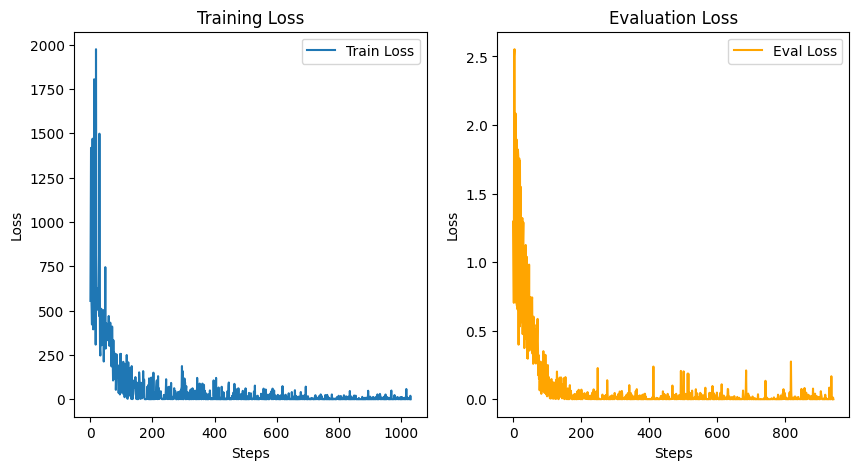

random_vanilla_uan [{'func_name': 'get_weather_forecast', 'func_description': 'Retrieves the weather forecast for a specific city.', 'func_parameters': [{'param_name': 'city', 'param_type': 'string'}], 'returns': [{'return_name': 'forecast', 'return_format': 'object'}]}, {'func_name': 'check_umbrella_needed', 'func_description': 'Checks if the forecast indicates a need for an umbrella.', 'func_parameters': [{'param_name': 'forecast_data', 'param_type': 'object'}], 'returns': [{'return_name': 'umbrella_needed', 'return_format': 'boolean'}]}, {'func_name': 'get_medication_id', 'func_description': 'Finds the ID for a medication.', 'func_parameters': [{'param_name': 'medication_name', 'param_type': 'string'}], 'returns': [{'return_name': 'medication_id', 'return_format': 'string'}]}, {'func_name': 'refill_prescription', 'func_description': 'Requests a prescription refill.', 'func_parameters': [{'param_name': 'medication_id', 'param_type': 'string'}, {'param_name': 'pharmacy_name', 'param_t

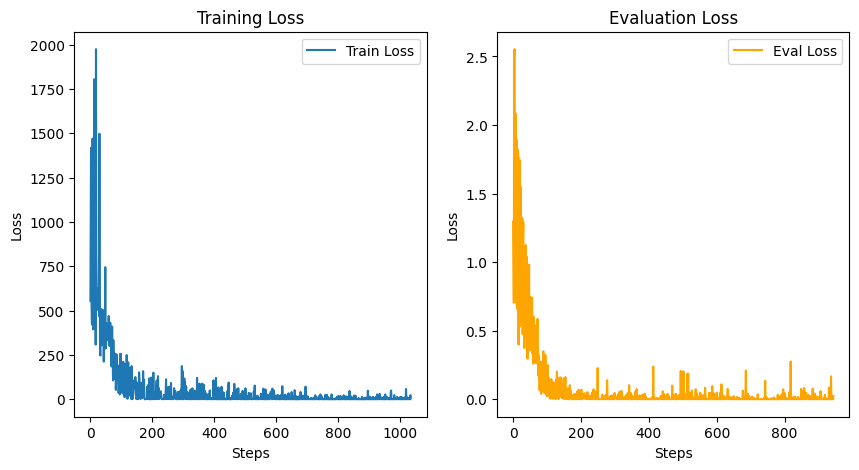

random_vanilla_uan [{'func_name': 'get_calories_in_food', 'func_description': 'Finds the calorie count for a given food item.', 'func_parameters': [{'param_name': 'food_name', 'param_type': 'string'}], 'returns': [{'return_name': 'calories', 'return_format': 'integer'}]}, {'func_name': 'get_user_orders', 'func_description': "Retrieves a list of the user's past orders.", 'func_parameters': [], 'returns': [{'return_name': 'orders', 'return_format': 'array'}]}, {'func_name': 'reorder_items', 'func_description': 'Reorders items from a past order.', 'func_parameters': [{'param_name': 'order_id', 'param_type': 'string'}], 'returns': [{'return_name': 'new_order_confirmation', 'return_format': 'object'}]}, {'func_name': 'search_flights', 'func_description': 'Finds flights for a given route and date.', 'func_parameters': [{'param_name': 'departure_city', 'param_type': 'string'}, {'param_name': 'arrival_city', 'param_type': 'string'}, {'param_name': 'departure_date', 'param_type': 'string'}], 'r

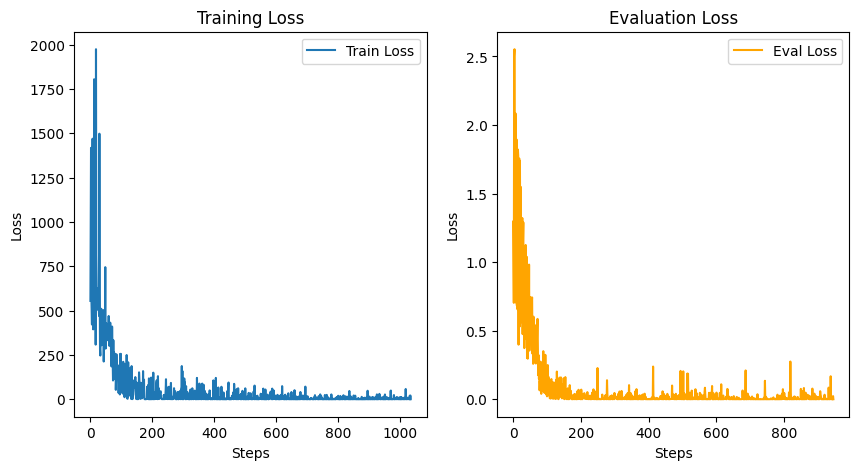

random_vanilla_uan [{'func_name': 'get_meeting_id', 'func_description': 'Finds the ID of a meeting.', 'func_parameters': [{'param_name': 'meeting_title', 'param_type': 'string'}], 'returns': [{'return_name': 'meeting_id', 'return_format': 'string'}]}, {'func_name': 'cancel_meeting', 'func_description': 'Cancels a scheduled meeting.', 'func_parameters': [{'param_name': 'meeting_id', 'param_type': 'string'}], 'returns': [{'return_name': 'cancellation_status', 'return_format': 'string'}]}, {'func_name': 'get_computer_specs', 'func_description': 'Retrieves the specifications of the current computer.', 'func_parameters': [], 'returns': [{'return_name': 'specs', 'return_format': 'object'}]}, {'func_name': 'get_running_containers', 'func_description': 'Lists all running Docker containers.', 'func_parameters': [], 'returns': [{'return_name': 'containers', 'return_format': 'array'}]}, {'func_name': 'stop_container', 'func_description': 'Stops a running Docker container.', 'func_parameters': [{'

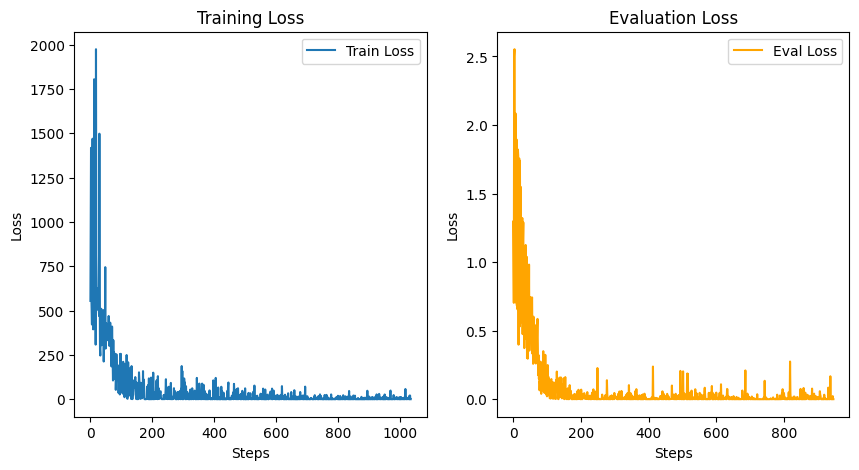

random_vanilla_uan [{'func_name': 'create_document', 'func_description': 'Creates a new document.', 'func_parameters': [{'param_name': 'title', 'param_type': 'string'}], 'returns': [{'return_name': 'document_url', 'return_format': 'string'}]}, {'func_name': 'request_review', 'func_description': 'Requests a review on a document.', 'func_parameters': [{'param_name': 'document_url', 'param_type': 'string'}, {'param_name': 'reviewer_email', 'param_type': 'string'}], 'returns': [{'return_name': 'request_status', 'return_format': 'string'}]}, {'func_name': 'do_nothing', 'func_description': 'This function does nothing and is used as a fallback when no other functions can be applied.', 'func_parameters': [], 'returns': []}]
random_vanilla [{'func_name': 'create_document', 'func_description': 'Creates a new document.', 'func_parameters': [{'param_name': 'title', 'param_type': 'string'}], 'returns': [{'return_name': 'document_url', 'return_format': 'string'}]}, {'func_name': 'request_review', 'f

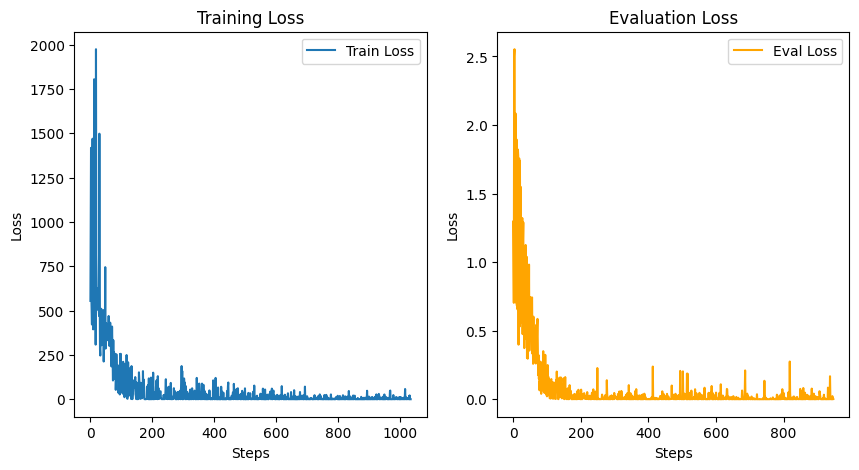

random_vanilla_uan [{'func_name': 'get_git_repository', 'func_description': 'Retrieves information about a git repository.', 'func_parameters': [{'param_name': 'repo_url', 'param_type': 'string'}], 'returns': [{'return_name': 'repo_info', 'return_format': 'object'}]}, {'func_name': 'get_latest_commit', 'func_description': 'Gets the latest commit from a repository.', 'func_parameters': [{'param_name': 'repo_id', 'param_type': 'string'}], 'returns': [{'return_name': 'commit_details', 'return_format': 'object'}]}, {'func_name': 'get_product_id', 'func_description': 'Finds a product ID by name.', 'func_parameters': [{'param_name': 'product_name', 'param_type': 'string'}], 'returns': [{'return_name': 'product_id', 'return_format': 'string'}]}, {'func_name': 'add_to_cart', 'func_description': 'Adds a product to the cart.', 'func_parameters': [{'param_name': 'product_id', 'param_type': 'string'}, {'param_name': 'quantity', 'param_type': 'integer'}], 'returns': [{'return_name': 'cart_status', 

In [ ]:
### MAIN TRAINING LOOP
optimizer=AdamW8bit(model.parameters(), lr=3e-4)
device="cuda:0"
#model,optimizer,device=accelerator.prepare(model,optimizer,device)

train_steps = 10000
losseestrain=[]
losseseval=[]
sequence_adverbs=["after","before","then","next","finally","meanwhile","subsequently","consequently","thereafter","simultaneously","initially","subsequent to","prior to","following","in the meantime","at the same time","in succession","in turn","in sequence","in order to","to begin with","to conclude with","to summarize","to sum up","to wrap up"]
max_ideas=3
batch_acc_steps=8
batch_tot_len=0
optimizer.zero_grad()
attend=False
attend_token="sequence:"
top_attend=0.7
top=0.8
normal_att_token="\nanswer:"
for i in range(train_steps):
    sequence=[]
    
    try:
     batch=train.sample(random.choice([1,2,3,4,5,6]))
    except:
     print("error sampling")
     continue
    random_functions=batch["functions"].values
    requests=batch["query"].values
    
    
    
   
    try:
     random_functions=[ast.literal_eval(f) for f in random_functions]
     random_functions=list(itertools.chain.from_iterable(random_functions))
     random_functions.append({"func_name":"do_nothing","func_description":"This function does nothing and is used as a fallback when no other functions can be applied.","func_parameters":[],"returns":[]})
     print("random_vanilla_uan",random_functions)
    except:
        print("error in random functions")
        continue
    #random_functions=list(itertools.chain.from_iterable(random_functions))
    random.shuffle(random_functions)
    print("random_vanilla",random_functions)
    random_functionss=json.dumps(random_functions).replace("\"", "\'")
    functions=random_functionss
    #join requests
    for j in range(max(len(requests)-2,0)):
       requests[j]=requests[j]+" "+random.choice(sequence_adverbs)
    requests=" ".join(requests[:-1]) if len(requests)>1 else requests[0]
    query=requests
    response=batch["response"].values[:-1] if len(batch["response"].values)>1 else batch["response"].values
    try:
        response=[ast.literal_eval(r) for r in response]
    except:
        print("error in response")
        continue
    response=list(itertools.chain.from_iterable(response))
    response=json.dumps(response).replace("\"", "\'")



    



    
    randomnumb=random.random()
    if randomnumb<0.3:
       rand_text_q=natural_language_dset.sample(1).text.values[0]
       query=rand_text_q
       response=[{"func_call": "do_nothing", "func_input": [],"needs_function":[],"func_param_mapping":[]}]
       response=json.dumps(response).replace("\"", "\'")
    
    

    template=f"""
functions: {functions},
query: '{query}',
answer: {response},
end:'True'
"""
    print(template)
    inputs = tokenizer(template, return_tensors="pt").to(model.device)
    labels = inputs.input_ids.detach().clone()
    idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode(normal_att_token)[2]).nonzero()[0]
    labels[0, :idxof_attend_token] = -100

    if attend:
        attend_token_index = (inputs.input_ids[0]==tokenizer.encode(attend_token)[2]).nonzero()[0]
        labels[0, :attend_token_index] = -100
        print(labels)
        print(tokenizer.encode(attend_token)[0])
    print("label shape",labels)
    inputs = inputs
    labels = labels
        # Forward pass
    with torch.amp.autocast(dtype=torch.float16,device_type="cuda"):
        
     outputs = model(**inputs, labels=labels)
    
    
    
    loss = outputs.loss*len(inputs.input_ids[0])
    loss.backward()
    batch_tot_len+=len(inputs.input_ids[0])
    losseestrain.append(loss.item())
    print("batch_tot_len",batch_tot_len)
    if (i + 1) % batch_acc_steps == 0:
       for param in model.parameters():
              if param.grad is not None:
                param.grad /= batch_tot_len
       optimizer.step()
       optimizer.zero_grad()
       batch_tot_len = 0
       clear_output()
        
    #eval loss
    try:
     batch=eval.sample(random.randint(1, max_ideas))
    except:
       print("error on eval sampling")
       continue
    random_functions=batch["functions"].values
    requests=batch["query"].values
    try:
     random_functions=[ast.literal_eval(f) for f in random_functions]
     random_functions=list(itertools.chain.from_iterable(random_functions))
     random_functions.append({"func_name":"do_nothing","func_description":"This function does nothing and is used as a fallback when no other functions can be applied.","func_parameters":[],"returns":[]})

    except:
        print("error in random functions")
        continue
    random.shuffle(random_functions)
    random_functionss=json.dumps(random_functions).replace("\"", "\'")
    functions=random_functionss
    #join requests
    for j in range(len(requests)-2):
         requests[j]=requests[j]+" "+random.choice(sequence_adverbs)
    requests=" ".join(requests)
    query=requests
    response=batch["response"].values
    try:
        response=[ast.literal_eval(r) for r in response]
    except:
        print("error in response")
        continue
    response=list(itertools.chain.from_iterable(response))
    response=json.dumps(response).replace("\"", "\'")
    randomnumb=random.random()
    if randomnumb<0.3:
         rand_text_q=natural_language_dset.sample(1).text.values[0]
         query=rand_text_q
         response= [{"func_call": "do_nothing", "func_input": [],"needs_function":[],"func_param_mapping":[]}]
         response=json.dumps(response).replace("\"", "\'")
    template=f"""
functions: {functions},
query: '{query}',
answer: {response},
end:'True'
"""
    inputs = tokenizer(template, return_tensors="pt").to(device)
    labels = inputs.input_ids.detach().clone()
    idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode(normal_att_token)[2]).nonzero()[0]
    labels[0, :idxof_attend_token] = -100
    inputs = inputs
    labels = labels
    with torch.no_grad():
        with torch.amp.autocast(dtype=torch.float16,device_type="cuda"):
     
         outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    losseseval.append(loss.item())
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(losseestrain, label='Train Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(losseseval, label='Eval Loss', color='orange')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Evaluation Loss')
    plt.legend()
    plt.show()


   
    

In [ ]:
model.device

In [ ]:
device

In [ ]:
print(device)

In [ ]:
print(outputs)

In [ ]:
from accelerate import Accelerator

In [ ]:
print((inputs.input_ids[0]==tokenizer.encode("\nanswer:")[2]).nonzero())

In [ ]:
tokenizer.encode("\nanswer:")

In [ ]:
model.eval()
model.save_pretrained("qwen_task_2")

In [ ]:
mod

In [ ]:
base_model=AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B",device_map="cuda",attn_implementation="flash_attention_2",torch_dtype=torch.bfloat16)
tokenizer= AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-0.6B")



In [ ]:
model = PeftModel.from_pretrained(base_model, "qwen_agent_sft_0.6b/qwen_task1")
model=model.merge_and_unload()
model.save_pretrained("qwen_task_1_merged_2")


In [ ]:
model=AutoModelForCausalLM.from_pretrained("qwen_task_1_merged_2",device_map="cuda",attn_implementation="flash_attention_2",torch_dtype=torch.bfloat16,quantization_config=quant_config)


In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
model.add_adapter("task_b",peft_config)

In [ ]:
def sim_dpo_loss(logits_w,logits_l,beta,y_W_index,y_l_index,gamma):
    logits_w=torch.log_softmax(logits_w, dim=1)
    logits_l=torch.log_softmax(logits_l, dim=1)
    log_w=logits_w[torch.arange(0, logits_w.size(0)), y_W_index].sum()
    log_l=logits_l[torch.arange(0, logits_l.size(0)), y_l_index].sum()
    log_w=log_w/y_W_index.shape[0]
    log_l=log_l/y_l_index.shape[0]
    #print("logits_w:", logits_w)
    print("logits_l:", log_l)
    print("logits_w:", log_w)


    ratio=(log_w - log_l)*beta
    print("ratio", torch.sigmoid(ratio-gamma))
    lossfirst=-torch.log(torch.sigmoid(ratio- gamma))
    
    return lossfirst 


In [ ]:
def insert_head_or_tail(a,b):
    for i in a:
        if random.choice([True, False]):
            b.append(i)
        else:
            b.insert(0, i)

In [ ]:
a=["a","b","c"]
b=["d","e","f"]
insert_head_or_tail(a,b)
print(b)

In [ ]:
model.merge_adapter("qwen_task1")

In [ ]:
print(test)


In [ ]:
#dpo
optimizer=AdamW8bit(model.parameters(), lr=9e-7)
train_steps =1
losseestrain=[]
losseseval=[]
sequence_adverbs=["after","before","then","next","finally","meanwhile","subsequently","consequently","thereafter","simultaneously","initially","subsequent to","prior to","following","in the meantime","at the same time","in succession","in turn","in sequence","in order to","to begin with","to conclude with","to summarize","to sum up","to wrap up"]
max_ideas=3
batch_acc_steps=8
batch_tot_len=0
optimizer.zero_grad()
attend=False
attend_token="sequence:"
top_attend=0.7
top=0.8
normal_att_token="answer:"
for i in range(train_steps):
    lossm=[]
    sequence=[]
    
    try:
     batch=train.sample(random.choice([1,2,3,4,5,6]))
    except:
     print("error sampling")
     continue
    random_functions=batch["functions"].values
    requests=batch["query"].values
    
    
    
   
    try:
     random_functions=[ast.literal_eval(f) for f in random_functions]
     random_functions=list(itertools.chain.from_iterable(random_functions))
     random_functions.append({"func_name":"do_nothing","func_description":"This function does nothing and is used as a fallback when no other functions can be applied.","func_parameters":[],"returns":[]})
     print("random_vanilla_uan",random_functions)
    except:
        print("error in random functions")
        continue
    #random_functions=list(itertools.chain.from_iterable(random_functions))
    random.shuffle(random_functions)
    print("random_vanilla",random_functions)
    random_functionss=json.dumps(random_functions).replace("\"", "\'")
    functions=random_functionss
    #join requests
    for j in range(max(len(requests)-2,0)):
       requests[j]=requests[j]+" "+random.choice(sequence_adverbs)
    requests=" ".join(requests[:-1]) if len(requests)>1 else requests[0]
    query=requests
    response=batch["response"].values[:-1] if len(batch["response"].values)>1 else batch["response"].values
    try:
        response=[ast.literal_eval(r) for r in response]
        response=list(itertools.chain.from_iterable(response))
        #random.shuffle(response)
        print("response",response)
        countfull_response=[]

        
        
    except:
        print("error in response")
        continue
    response_W=response.copy()
    response_W=json.dumps(response).replace("\"", "\'")
    #print(countfull_response)
    #choose_W_index=random.sample(countfull_response, k=random.randint(1, len(countfull_response)))
    response_l=response.copy()[:-random.randint(1, len(response)-1)] if len(response)>1 else response.copy()
    if len(batch["response"].values)>0:
       try:
      
        values_to_insert=[responsed["needs_function"] for responsed in response if len(responsed["needs_function"])>0]
        param_mapping=[responsed["func_param_mapping"] for responsed in response if len(responsed["func_param_mapping"])>0]
        values_to_insert=list(itertools.chain.from_iterable(values_to_insert))
        param_mapping=list(itertools.chain.from_iterable(param_mapping))
        random.shuffle(values_to_insert)
        print(len(values_to_insert))
        if len(values_to_insert)>0:
         for response_k in response_l:
           randn= random.random()
           if randn<0.2:
               response_k["needs_function"]=random.sample(values_to_insert, k=random.randint(1, len(values_to_insert)))
           randn=random.random()
           if randn<0.5:
               response_k["func_param_mapping"]=random.sample(param_mapping, k=random.randint(1, len(param_mapping)))
        values_to_insert=random.sample(values_to_insert, k=random.randint(1, len(values_to_insert)))
        print("values_to_insert", values_to_insert)
        

        
        
        insert_head_or_tail(values_to_insert, response_l)
       except:
        print("error in last_val")
        continue
      
    
    response_l=[recursive_random_drop(r, drop_prob=0.1) for r in response_l]
    
          
       
    response_l=json.dumps(response_l).replace("\"", "\'")
    #print("response_W",response_W)
    #print("response_l",response_l)



    



    
    randomnumb=random.random()
    if randomnumb<0.0:
       rand_text_q=natural_language_dset.sample(1).text.values[0]
       query=rand_text_q
       response=[{"func_call": "do_nothing", "func_input": [],"needs_function":[],"func_param_mapping":[]}]
       response=json.dumps(response).replace("\"", "\'")
    
    

    template_w=f"""
functions: {functions},
query: '{query}',
answer: {response_W},
end:'True'
"""
    template_l=f"""
format:[{[{"functions":{"func_name":"string","func_description":"string","func_parameters":"list","returns":"list"}},{"response": {"func_call":"string","func_input":"list","needs_function":"list","func_param_mapping":"list"}}]}],
context:'your mission is to answer the query using the functions provided, if you cannot answer the query with the functions, use the do_nothing function. If you need the output of a function for a subsequent function, use the needs_function and func_param_mapping fields in the response. Remember that functions and response have different fields, so do not mix them up. You can only use the functions provided to answer the query, do not make up new answers.',
functions: {functions},
query: '{query}',
answer: {response_l},
end:'True'
"""
    print(template_w)
    print("template_l", template_l)

    inputs_w = tokenizer(template_w, return_tensors="pt").to("cuda")
    inputs_l = tokenizer(template_l, return_tensors="pt").to("cuda")
    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
     outputs_w = model(**inputs_w)
     outputs_l = model(**inputs_l)
    #logits
    logits_w = outputs_w.logits
    logits_l = outputs_l.logits
    ref_token=tokenizer.encode(normal_att_token)[0]
    y_w_index=(inputs_w.input_ids[0]==ref_token).nonzero()[0]
    y_l_index=(inputs_l.input_ids[0]==ref_token).nonzero()[0]
    print("y_w_index", y_w_index)
    print("y_l_index", y_l_index)
    logits_w= logits_w[0, y_w_index:, :]
    logits_w=logits_w[:-1, :]
    print(logits_w.shape)
    logits_l= logits_l[0, y_l_index:, :]
    logits_l=logits_l[:-1, :]
    print("inputs_w",inputs_w)
    

    inputs_w=inputs_w.input_ids[:, y_w_index:].view(-1)
    inputs_w=inputs_w[1:]
    inputs_l=inputs_l.input_ids[:, y_l_index:].view(-1)
    inputs_l=inputs_l[1:]
    print("inputs_w shape", inputs_w.shape[0])
    print("inputs_l shape", inputs_l.shape[0])
    #print("logits_w shape", logits_w.shape)
    print("inputs_w_2", inputs_w)

    lossv=sim_dpo_loss(logits_w, logits_l, 3, inputs_w, inputs_l, 0.1)/batch_acc_steps
    print("lossv", lossv.item())
    lossv.backward()
    lossm.append(lossv.item())


    

    
    
    if (i + 1) % batch_acc_steps == 0:
       torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
       optimizer.step()
       optimizer.zero_grad()
       batch_tot_len = 0
       lossm_avg = sum(lossm) / len(lossm)
       lossm = []
       losseestrain.append(lossm_avg)
       clear_output()
        
    #eval loss
    try:
     batch=eval.sample(random.randint(1, max_ideas))
    except:
       print("error on eval sampling")
       continue
    random_functions=batch["functions"].values
    requests=batch["query"].values
    try:
     random_functions=[ast.literal_eval(f) for f in random_functions]
     random_functions=list(itertools.chain.from_iterable(random_functions))
     random_functions.append({"func_name":"do_nothing","func_description":"This function does nothing and is used as a fallback when no other functions can be applied.","func_parameters":[],"returns":[]})

    except:
        print("error in random functions")
        continue
    random.shuffle(random_functions)
    random_functionss=json.dumps(random_functions).replace("\"", "\'")
    functions=random_functionss
    #join requests
    for j in range(len(requests)-1):
         requests[j]=requests[j]+" "+random.choice(sequence_adverbs)
    requests=" ".join(requests)
    query=requests
    response=batch["response"].values
    try:
        response=[ast.literal_eval(r) for r in response]
    except:
        print("error in response")
        continue
    response=list(itertools.chain.from_iterable(response))
    response=json.dumps(response).replace("\"", "\'")
    randomnumb=random.random()
    if randomnumb<0.3:
         rand_text_q=natural_language_dset.sample(1).text.values[0]
         query=rand_text_q
         response= [{"func_call": "do_nothing", "func_input": [],"needs_function":[],"func_param_mapping":[]}]
         response=json.dumps(response).replace("\"", "\'")
    template=f"""
format:[{[{"functions":{"func_name":"string","func_parameters":"list","returns":"list"}},{"response": {"func_call":"string","func_input":"list","needs_function":"list","func_param_mapping":"list"}}]}],
context:'your mission is to answer the query using the functions provided, if you cannot answer the query with the functions, use the do_nothing function, if you need the output of a function for a subsequent function, use the needs_function and func_param_mapping fields in the response. remember that functions and response have different fields, so do not mix them up. You can only use the functions provided to answer the query, do not make up new answers.',
functions: {functions},
query: '{query}',
answer: {response},
end:'True'
"""
    inputs = tokenizer(template, return_tensors="pt")
    labels = inputs.input_ids.detach().clone()
    idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode(normal_att_token)[2]).nonzero()[0]
    labels[0, :idxof_attend_token] = -100
    inputs = inputs.to("cuda")
    labels = labels.to("cuda")
    with torch.no_grad():
     with torch.amp.autocast("cuda", dtype=torch.bfloat16):
      outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    losseseval.append(loss.item())
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(losseestrain, label='Train Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(losseseval, label='Eval Loss', color='orange')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Evaluation Loss')
    plt.legend()
    plt.show()
#REMEMBER TO TEST GAN FOR THIS TASK

   

In [ ]:
idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode("\nanswer:")[2]).nonzero()

In [ ]:
print("idxof_attend_token", idxof_attend_token)

In [ ]:
print(tokenizer.encode("\nanswer"))

In [3]:
#always
testset= pd.read_csv("/kaggle/input/project-dataset/qwen_fine_data.csv")
seq_log=testset.dropna()
data= pd.read_csv("/kaggle/input/project-dataset/qwen_def_data.csv")
data=data.sample(frac=1).reset_index(drop=True)
train,eval=data[:int(len(data)*0.9)],data[int(len(data)*0.9):]
natural_language_dset=pd.read_csv("/kaggle/input/project-dataset/qwen_nat_lang.csv")



In [ ]:
accelerator=Accelerator(mixed_precision="bf16")

In [ ]:
# x lora alternative
quant_config = HqqConfig(
    nbits=4,group_size=64)

In [4]:
#fusion alternative
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

In [6]:
#always

model,tokenizer= FastLanguageModel.from_pretrained(
    "microsoft/Phi-3-mini-128k-instruct",device_map="cuda",load_in_4bit=True)
#tokenizer= AutoTokenizer.from_pretrained(
    #"microsoft/Phi-3-mini-128k-instruct")

==((====))==  Unsloth 2025.3.14: Fast Phi3 patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

microsoft/Phi-3-mini-128k-instruct does not have a padding token! Will use pad_token = <|placeholder6|>.


In [7]:
model=FastLanguageModel.get_peft_model(
    model,
    r=8,
    target_modules=["o_proj","qkv_proj","up_proj"],
    use_gradient_checkpointing="unsloth"
)

Unsloth: Making `model.base_model.model.model` require gradients


In [ ]:
model=prepare_pippy(model)

In [ ]:
#fusion alternative
lora_config=adapters.LoRAConfig(
    r=7,
    alpha=40,
    dropout=0.3,
    selfattn_lora=True,
    intermediate_lora=True,
    output_lora=True,
    attn_matrices=["q","k","v"],
    dtype="bfloat16"
)
adapters.init(model)
model.add_adapter("qwen_task1", lora_config)
model.add_adapter("qwen_task2", lora_config)
model.train_adapter("qwen_task1")
model.set_active_adapters("qwen_task1")
model=model.to("cuda")
model.gradient_checkpointing_enable()




In [ ]:
randlora_config = RandLoraConfig(
    r=16,
    randlora_alpha=240,
    randlora_dropout=0.2,
    target_modules=["q_proj", "k_proj", "v_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
    
)
model = get_peft_model(model, randlora_config)
model.print_trainable_parameters()
model.gradient_checkpointing_enable()


In [8]:
model.print_trainable_parameters()

trainable params: 4,718,592 || all params: 3,825,798,144 || trainable%: 0.1233


In [ ]:
#fusion alternative
print(model.adapter_summary())

In [ ]:
#create fusion
adapters.init(model)
model.load_adapter("qwen_agent_sft_0.6b/qwen_task1")
model.load_adapter("qwen_agent_sft_0.6b/qwen_task2")
adapter_setup=adapters.composition.Fuse("qwen_task1", "qwen_task2")
model.add_adapter_fusion(adapter_setup)
model.train_adapter_fusion(adapter_setup)
model.gradient_checkpointing_enable()
#NOW RUN THE MAIN TRAINING LOOP

In [ ]:
model.train_adapter_fusion()

In [ ]:
#fusion alternative
print(model.adapter_summary())

In [ ]:
peft_config=IA3Config(
    
    target_modules=["o_proj", "qkv_proj", "gate_up_proj", "down_proj"],
    feedforward_modules=["gate_up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

In [ ]:
#x lora alternative

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
model.gradient_checkpointing_enable()


In [ ]:
print(model.device)
for i,j in model.named_parameters():
    print(i)

In [ ]:
#text segmentation
optimizer=AdamW8bit(model.parameters(), lr=1e-5)
train_steps =20000
losseestrain=[]
losseseval=[]
sequence_adverbs=["after","before","then","next","finally","meanwhile","subsequently","consequently","thereafter","simultaneously","initially","subsequent to","prior to","following","in the meantime","at the same time","in succession","in turn","in sequence","in order to","to begin with","to conclude with","to summarize","to sum up","to wrap up"]
max_ideas=10
batch_acc_steps=11
batch_tot_len=0
optimizer.zero_grad()
attend_token="answer:"
eval_module=10
range_mod=3
lossesevalmomentum=[]
losseestrainmomentum=[]
for i in range(train_steps):
    boolean_test=not( i%eval_module in range(range_mod))
    batch=train.sample(random.randint(1, max_ideas)) if boolean_test else eval.sample(random.randint(1, max_ideas))
    queriesv=batch["query"].values
    queries=[q+" "+random.choice(sequence_adverbs)  if d<len(queriesv)-1 else q for d,q in enumerate(queriesv)]
    numeratedq=["{}: {}".format(i+1, q) for i, q in enumerate(queriesv)]
    response="\n".join(numeratedq)
    queries=" ".join(queries)
    template=f"""
text:'{queries}',
answer:'{response}',
end:'True'
"""
    print("template", template,"eval:", not(boolean_test))

    inputs=tokenizer(template, return_tensors="pt").to("cuda")
    labels = inputs.input_ids.detach().clone()
    
    #print("inputs", inputs.input_ids.shape)
    #print("token", tokenizer.encode(attend_token)[0])
    idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode(attend_token)[0]).nonzero()[0][0]
    #print("idxof_attend_token", idxof_attend_token)
    
    labels[0, :idxof_attend_token] = -100
    #print("labels", labels)
    if not boolean_test:
        with torch.no_grad():
            outputs = model(**inputs, labels=labels)
            loss = outputs.loss
            lossesevalmomentum.append(loss.item())
    else:
        predict=model(**inputs, labels=labels)
        loss = predict.loss*(labels[0,idxof_attend_token:].shape[0])
        print("loss", loss.item())

        loss.backward()
        batch_tot_len+=labels[0,idxof_attend_token:].shape[0]
        losseestrainmomentum.append(loss.item())
    if (i + 1) % batch_acc_steps == 0:
       for param in model.parameters():
              if param.grad is not None:
                param.grad /= batch_tot_len
       moving_avg_train= sum(losseestrainmomentum) / len(losseestrainmomentum)
       losseestrain.append(moving_avg_train)
       losseestrainmomentum = []
       print("moving_avg_train", moving_avg_train)
       moving_avg_eval= sum(lossesevalmomentum) / len(lossesevalmomentum)
       losseseval.append(moving_avg_eval)
       lossesevalmomentum = []
       print("moving_avg_eval", moving_avg_eval)
       torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
       optimizer.step()
       optimizer.zero_grad()
       batch_tot_len = 0
       clear_output()
       plt.figure(figsize=(10, 5))
       plt.subplot(1, 2, 1)
       plt.plot(losseestrain, label="Train Loss")
       
       plt.legend()
       plt.subplot(1, 2, 2)
       plt.plot(losseseval, label="Eval Loss", color='orange')
       plt.legend()
       plt.show()


In [ ]:
model.training

In [ ]:
model.train()

In [ ]:
model.eval()
model.save_pretrained("qwen_agent_sft_0.6b/qwen_task_text_segmentation")
#RESTART KERNEL AND RUN ALWAYS AND X LORA ALTERNATIVE



In [ ]:
#fusion alternative
model.save_adapter("qwen_agent_sft_0.6b/qwen_task1", "qwen_task1")
model.train_adapter("qwen_task2")
model.set_active_adapters("qwen_task2")

In [ ]:
#fusion alternative
print(model.adapter_summary())

In [ ]:
#agentic behavior
optimizer=AdamW8bit(model.parameters(), lr=1e-4)
train_steps =20000
losseestrain=[]
losseseval=[]
max_ideas=5
batch_acc_steps=11
batch_tot_len=0
optimizer.zero_grad()
attend_token="answer:"
eval_module=10
range_mod=3
lossesevalmomentum=[]
losseestrainmomentum=[]
for i in range(train_steps):
    boolean_test=not( i%eval_module in range(range_mod))
    batch=train.sample(random.randint(1, max_ideas)) if boolean_test else eval.sample(random.randint(1, max_ideas))
    query=batch["query"].values[0]
    response=batch["response"].values[0].replace("false", "False").replace("true", "True")
    functions=batch["functions"].values
    functions=[ast.literal_eval(f) for f in functions]
    functions=list(itertools.chain.from_iterable(functions))
    functions.append({"func_name":"do_nothing","func_description":"This function does nothing and is used as a fallback when no other functions can be applied.","func_parameters":[],"returns":[]})
    random.shuffle(functions)
    functions=json.dumps(functions).replace("\"", "\'").replace("false", "False").replace("true", "True")
    print("response", response)
    response=ast.literal_eval(response)
    response=json.dumps(response).replace("\"", "\'")
    if random.random()<0.3:
        rand_text_q=natural_language_dset.sample(1).text.values[0]
        query=rand_text_q
        response=[{"func_call": "do_nothing", "func_input": [],"needs_function":[],"func_param_mapping":[]}]
        response=json.dumps(response).replace("\"", "\'")
    template=f"""
functions: {functions},
query: '{query}',
answer: {response},
end:'True'
"""
    print("template", template,"eval:", not(boolean_test))
    inputs=tokenizer(template, return_tensors="pt").to("cuda")
    labels = inputs.input_ids.detach().clone()
    idxof_attend_token = (inputs.input_ids[0]==tokenizer.encode(attend_token)[0]).nonzero()[0][0]
    labels[0, :idxof_attend_token] = -100
    if not boolean_test:
        with torch.no_grad():
            outputs = model(**inputs, labels=labels)
            loss = outputs.loss
            lossesevalmomentum.append(loss.item())
    else:
        predict=model(**inputs, labels=labels)
        loss = predict.loss*(labels[0,idxof_attend_token:].shape[0])
        print("loss", loss.item())

        loss.backward()
        batch_tot_len+=labels[0,idxof_attend_token:].shape[0]
        losseestrainmomentum.append(loss.item())
    if (i + 1) % batch_acc_steps == 0:
       for param in model.parameters():
              if param.grad is not None:
                param.grad /= batch_tot_len
       moving_avg_train= sum(losseestrainmomentum) / len(losseestrainmomentum)
       losseestrain.append(moving_avg_train)
       losseestrainmomentum = []
       print("moving_avg_train", moving_avg_train)
       moving_avg_eval= sum(lossesevalmomentum) / len(lossesevalmomentum)
       losseseval.append(moving_avg_eval)
       lossesevalmomentum = []
       print("moving_avg_eval", moving_avg_eval)
       torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
       optimizer.step()
       optimizer.zero_grad()
       batch_tot_len = 0
       clear_output()
       plt.figure(figsize=(10, 5))
       plt.subplot(1, 2, 1)
       plt.plot(losseestrain, label="Train Loss")
       
       plt.legend()
       plt.subplot(1, 2, 2)
       plt.plot(losseseval, label="Eval Loss", color='orange')
       plt.legend()
       plt.show()


In [ ]:
#x lora alternative
model.eval()
model.save_pretrained("qwen_agent_sft_0.6b/qwen_task_agentic_behavior")
#RESTART KERNEL AND RUN ALWAYS AND X LORA ALT FROM HERE

In [ ]:
#fusion alternative
model.save_adapter("qwen_agent_sft_0.6b/qwen_task2", "qwen_task2")
#restart and run always and the create fusion cell

In [ ]:
model.config.use_cache = False

In [ ]:
#x lora alternative
peft_config = xlora.xLoRAConfig(
    base_model_id="Qwen/Qwen3-0.6B",
    device=torch.device("cuda"),
    hidden_size=model.config.hidden_size,
    xlora_depth=4,
    adapters={
        "task_1":"./qwen_agent_sft_0.6b/qwen_task_text_segmentation",
        "adapter_2":"./qwen_agent_sft_0.6b/qwen_task_agentic_behavior"
    })
model = xlora.add_xlora_to_model(model=model, xlora_config=peft_config,verbose=True).to("cuda")
model.print_trainable_parameters()
model.gradient_checkpointing_enable()
#NOW RUN MAIN TRAINING LOOP

In [ ]:
ia3conf = None


In [ ]:
model=PeftModel.from_pretrained(model, "qwen_agent_sft_0.6b/qwen_task_text_segmentation",adapter_name="task_1").cpu()
model.load_adapter("qwen_agent_sft_0.6b/qwen_task_agentic_behavior",adapter_name="task_2")
model.add_weighted_adapter(["task_1", "task_2"], [0.3, 0.7],"merged",combination_type="ties",density=0.2)
model.set_adapter("merged")



In [ ]:
model=model.to("cuda")

In [ ]:
model=PeftModel.from_pretrained(model, "qwen_agent_sft_0.6b/qwen_task_agentic_behavior")
model.gradient_checkpointing_enable()

In [ ]:
model.save_pretrained("qwen_agent_sft_0.6b/qwen_task_merged")

In [ ]:
queries="turn on the tv, then turn on the lights, finally turn on the computer"
template=f"""
text:'{queries}',
answer:'
"""

In [ ]:
tokenized_inputs = tokenizer(template, return_tensors="pt").to("cuda")
outputs = model.generate(**tokenized_inputs, max_new_tokens=100, do_sample=False, temperature=0.1)
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)

In [ ]:
[1,2,3][0:]

In [ ]:
torch.log(torch.tensor(0.5))

In [ ]:
tokenizer.decode(torch.max(logits_w, dim=1).indices)

In [ ]:
tokenizer.decode([25])

In [ ]:
tokenizer.decode(inputs_w)

In [ ]:
[1,2,3][0:]

In [ ]:
list(range(0))

In [ ]:
batch["response"].values[-1]


In [ ]:
print(logits_w[torch.arange(logits_w.shape[0]),inputs_w])

In [ ]:
model.train()

In [ ]:
print(logits_w[1,torch.argmax(logits_w[1])])

In [ ]:
print(inputs_w)

In [ ]:
print(logits_w.shape)

In [ ]:
print(inputs_w.shape)

In [ ]:
tokenizer.decode(inputs_w[1:])

In [ ]:
inputs_w

In [ ]:
(inputs_w==tokenizer.encode("response:")[0]).nonzero()

In [ ]:
tokenizer.encode("response:")

In [ ]:
tokenizer.decode(inputs_l)

In [ ]:

#triangular att mask
tokenizer.batch

In [ ]:
print(outputs_w.logits.shape)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
#get occupied vram space
torch.cuda.memory_allocated()

In [ ]:
model.save_pretrained("qwen_agent_sft_0.6b")

In [ ]:
model.training

In [ ]:
model.eval()

In [ ]:
-{}

In [ ]:
model=AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM3-3B",device_map="cuda",attn_implementation="flash_attention_2",quantization_config=quant_config)

In [ ]:
model=PeftModel.from_pretrained(
    model,
    "rem_smolm_agent_metat_composed_1",
    is_trainable=True
)


In [ ]:
from numba import cuda

In [ ]:
device = cuda.get_current_device()
device.reset()

In [ ]:
model

In [ ]:
model=model.merge_and_unload()

In [ ]:
model.get_use_trainable_adapters()

In [ ]:
model.save_pretrained("rem_merged_do_nothing_function_metat_composed_1_smolm")

In [ ]:
model=AutoModelForCausalLM.from_pretrained(
    "").cuda()

In [ ]:
tokenizer= AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM3-3B")

In [10]:
functions=[

    {
        "func_name": "do_nothing",
        "func_description": "This function does nothing and is used as a fallback when no other functions can be applied.",
        "func_parameters": [],
        "returns":[]
    }
    ,
    {
        "func_name": "make_a_phone_call",
        "func_description": "This function makes a phone call to a contact given his name",
        "func_parameters":[{"param_name": "contact_name", "param_type": "string"}],
        "returns": [],
    },
    {
        "func_name":"play_tv_show",
        "func_description": "This function plays a TV show given its name.",
        "func_parameters":[{"param_name": "tv_show_name", "param_type": "string"}],
        "returns": []
    },
    {
        "func_name":"save_document",
        "func_description": "This function saves a document with the given data and file name.",
        "func_parameters":[{"param_name": "document", "param_type": "string"},{"param_name":"file_name","param_type":"string"}],
        "returns": [{"return_name": "is_it_successful?", "return_format": "string"}]
    },
    {
        "func_name":"give_food_to_pet",
        "func_description": "This function gives food to a pet given his name and the food's name.",
        "func_parameters":[{"param_name":"food_name","param_type":"string"},{"param_name":"dog_name","param_type":"string"}],
        "returns":[]
    },
    {"func_name":"get_status_document",
        "func_description":"This function retrieves the status of a dog in a document.",
        "func_parameters":[{"param_name":"dog_name","param_type":"string"}],
        "returns":[{"return_name":"dog_status","return_format":"string"}]
     },
     {
         "func_name":"find_album",
            "func_description":"This function finds an album by the artist and album name.",
            "func_parameters":[{"param_name":"artist_name","param_type":"string"},{"param_name":"album_name","param_type":"string"}],
            "returns":[{"return_name":"album_details","return_format":"string"}]
        
     },
     {
         "func_name":"play_album",
            "func_description":"This function plays an album and returns whether it was successful.",
            "func_parameters":[{"param_name":"album_details","param_type":"string"}],
            "returns":[{"return_name":"is_it_successful?","return_format":"string"}]
     },
     

     
]
functions=json.dumps(functions).replace("\"","'")
query="give food to my pet toby, feed him with chicken. then, save his status  in a file named 'toby.txt'. Finally turn on the tv and put the truman show."
template=f"""
functions: {functions},
query: '{query}',
""" + """answer:"""


In [ ]:
model.training

In [ ]:
model.train()

In [11]:
testtext=template
inputs = tokenizer(testtext, return_tensors="pt").to("cuda")

with torch.amp.autocast("cuda", dtype=torch.float16):
    
 prediction= model.generate(**inputs, max_new_tokens=300,tokenizer=tokenizer,stop_strings=["end:'True'"],do_sample=False,top_p=0.8,temperature=0.7,top_k=20)
print(tokenizer.decode(prediction[0], skip_special_tokens=True))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



functions: [{'func_name': 'do_nothing', 'func_description': 'This function does nothing and is used as a fallback when no other functions can be applied.', 'func_parameters': [], 'returns': []}, {'func_name': 'make_a_phone_call', 'func_description': 'This function makes a phone call to a contact given his name', 'func_parameters': [{'param_name': 'contact_name', 'param_type': 'string'}], 'returns': []}, {'func_name': 'play_tv_show', 'func_description': 'This function plays a TV show given its name.', 'func_parameters': [{'param_name': 'tv_show_name', 'param_type': 'string'}], 'returns': []}, {'func_name': 'save_document', 'func_description': 'This function saves a document with the given data and file name.', 'func_parameters': [{'param_name': 'document', 'param_type': 'string'}, {'param_name': 'file_name', 'param_type': 'string'}], 'returns': [{'return_name': 'is_it_successful?', 'return_format': 'string'}]}, {'func_name': 'give_food_to_pet', 'func_description': 'This function gives 

In [ ]:
tokenizer.encode("[{'")

In [ ]:
print("hello")

In [ ]:
model.save_pretrained("rem_qwen3-4b_agent_metat_composed_1")

In [ ]:
model.print_trainable_parameters()

In [ ]:
model.merge_and_unload()

In [ ]:
#backup
model.save_pretrained("qwen_sft_simpo_2")

In [ ]:
text=functions
text=json.dumps(text)
functions = ast.literal_eval(text)
print(functions)


In [ ]:
#inverse process
stringified = json.dumps(functions["functions"]).replace("\"", "\'")
print(stringified)
print(ast.literal_eval(stringified))